# 🗑️🤖 Garbage Image Classification


# 🎚️ 1. Environment Setup


## Dependencies


In [1]:
import json
import math
import os
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from ai_edge_litert.interpreter import Interpreter
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.data import Dataset
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet_v2 import (
    EfficientNetV2S,
    preprocess_input,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


/home/dev/ML/Experimental/GarbageImageClassification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-08 04:52:20.800461: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-08 04:52:21.053667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786139541.183634     967 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786139541.21254

## Configuration


### Device (GPU)

In [2]:
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [3]:
gpus = tf.config.list_physical_devices("GPU")
print("Number of GPUs available:", len(gpus))


Number of GPUs available: 1


In [4]:
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print("Error setting memory growth:", e)


Memory growth enabled for GPUs.


### Project Paths

In [5]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"

RAW_DIR = DATA_DIR / "raw"
SPLITS_DIR = DATA_DIR / "splits"
DATASETS_DIR = DATA_DIR / "datasets"

TRAIN_DS_DIR = DATASETS_DIR / "train"
VAL_DS_DIR = DATASETS_DIR / "validation"
TEST_DS_DIR = DATASETS_DIR / "test"

OUTPUTS_DIR = PROJECT_DIR / "outputs"

CONFIGS_DIR = OUTPUTS_DIR / "configs"
CHECKPOINTS_DIR = OUTPUTS_DIR / "checkpoints"
LOGS_DIR = OUTPUTS_DIR / "logs"
HISTORY_DIR = OUTPUTS_DIR / "history"
MODELS_DIR = OUTPUTS_DIR / "models"
SAVED_MODEL_DIR = OUTPUTS_DIR / "saved_model"
TFLITE_DIR = OUTPUTS_DIR / "tflite"
TFJS_DIR = OUTPUTS_DIR / "tfjs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

TRAIN_DF_PATH = SPLITS_DIR / "train.csv"
VAL_DF_PATH = SPLITS_DIR / "validation.csv"
TEST_DF_PATH = SPLITS_DIR / "test.csv"

CLASS_WEIGHTS_PATH = CONFIGS_DIR / "class_weights.json"

INITIAL_MODEL_PATH = MODELS_DIR / "initial.keras"
BEST_MODEL_PATH = MODELS_DIR / "best.keras"
FINAL_MODEL_PATH = MODELS_DIR / "final.keras"

INITIAL_HISTORY_PATH = HISTORY_DIR / "initial_history.json"
HISTORY_JSON_PATH = HISTORY_DIR / "history.json"
HISTORY_CSV_PATH = HISTORY_DIR / "history.csv"

TFLITE_MODEL_PATH = TFLITE_DIR / "model.tflite"
TFLITE_LABEL_PATH = TFLITE_DIR / "label.txt"

DATASET_NAME = "garbage-classification-v2"

RAW_DATASET_DIR = RAW_DIR / DATASET_NAME
RAW_IMAGE_DIR = RAW_DATASET_DIR / "original"


In [6]:
DIRECTORIES = [
    RAW_DIR,
    SPLITS_DIR,
    DATASETS_DIR,
    CONFIGS_DIR,
    CHECKPOINTS_DIR,
    LOGS_DIR,
    HISTORY_DIR,
    MODELS_DIR,
    SAVED_MODEL_DIR,
    TFLITE_DIR,
    TFJS_DIR,
    FIGURES_DIR,
]

for dir in DIRECTORIES:
    dir.mkdir(parents=True, exist_ok=True)


### Reproducibility

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


### Training


In [ ]:
IMG_SIZE = (384, 384)
BATCH_SIZE = 16

BACKBONE_TRAINABLE_RATIO = 0.2
DROPOUT_RATE = 0.3

EPOCHS = 20
INITIAL_LR = 1e-3
INITIAL_WD = 1e-4

MIN_LR = 1e-7
LR_REDUCE_FACTOR = 0.2
LR_REDUCE_PATIENCE = 2

FINE_TUNE_EPOCHS = 30
FINE_TUNE_LR = 1e-5
FINE_TUNE_WD = 5e-5

EARLY_STOPPING_PATIENCE = 5


In [9]:
def create_callbacks(best_loss=None):

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=LR_REDUCE_FACTOR,
            patience=LR_REDUCE_PATIENCE,
            min_lr=MIN_LR,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=CHECKPOINTS_DIR / "epoch_{epoch:03d}.keras",
            verbose=1,
        ),
        tf.keras.callbacks.TensorBoard(
            log_dir=LOGS_DIR,
            histogram_freq=1,
        ),
    ]

    checkpoint_kwargs = {
        "filepath": BEST_MODEL_PATH,
        "monitor": "val_loss",
        "save_best_only": True,
        "verbose": 1,
    }

    if best_loss is not None:
        checkpoint_kwargs["initial_value_threshold"] = best_loss

    callbacks.append(ModelCheckpoint(**checkpoint_kwargs))

    return callbacks


### Dataset


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = [
    "battery",
    "biological",
    "cardboard",
    "clothes",
    "glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash",
]

NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}


In [11]:
def load_image_tensor(image_path):

    img = tf.io.read_file(image_path)

    img = tf.io.decode_image(img, channels=3, expand_animations=False)

    img.set_shape([None, None, 3])

    img = tf.image.resize(img, IMG_SIZE)

    img = tf.cast(img, tf.float32)

    return img


def preprocess_image(img):

    return preprocess_input(img)


# 🗄️ 2. Data Collection


## Data Loading


In [12]:
kagglehub.dataset_download(
    "sumn2u/garbage-classification-v2", output_dir=str(RAW_DATASET_DIR)
)


'/home/dev/ML/Experimental/GarbageImageClassification/data/raw/garbage-classification-v2'

## Dataset Classes

In [13]:
classes = sorted(
    name
    for name in os.listdir(RAW_IMAGE_DIR)
    if os.path.isdir(os.path.join(RAW_IMAGE_DIR, name))
)

assert CLASS_NAMES == classes

print("Number of classes:", len(classes))
print(classes)


Number of classes: 10
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


## Dataset Index

In [14]:
records = []

for cls in CLASS_NAMES:
    class_dir = RAW_IMAGE_DIR / cls

    for img_path in class_dir.glob("*.*"):
        records.append((str(img_path), cls))

df = pd.DataFrame(records, columns=["filepath", "class_name"])

df.sample(5)


,filepath,class_name
2536,/home/dev/ML/Experimental/GarbageImageClassifi...,cardboard
1210,/home/dev/ML/Experimental/GarbageImageClassifi...,biological
7782,/home/dev/ML/Experimental/GarbageImageClassifi...,paper
11932,/home/dev/ML/Experimental/GarbageImageClassifi...,trash
4901,/home/dev/ML/Experimental/GarbageImageClassifi...,glass


# 🔍 3. Data Exploration

## Number of Images


In [15]:
print(f"Total images: {len(df):,}")


Total images: 12,259


## Sample Images


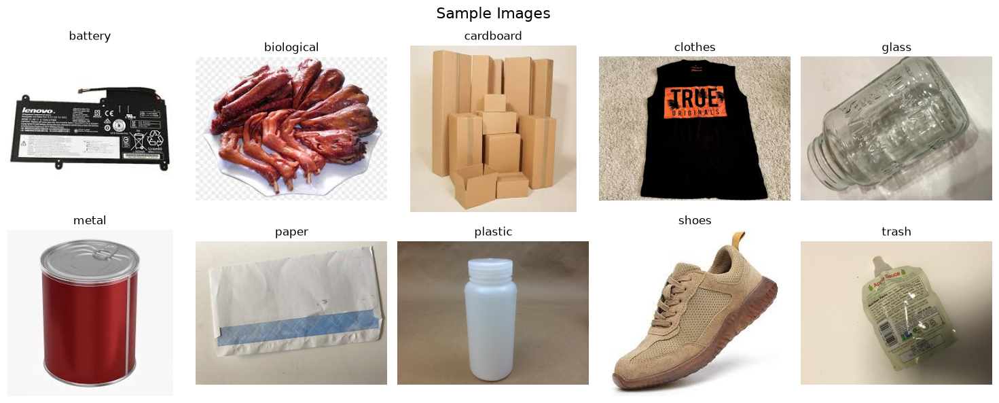

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, cls in zip(axes.ravel(), CLASS_NAMES):
    class_dir = RAW_IMAGE_DIR / cls
    img_path = random.choice(list(class_dir.glob("*.*")))
    img = keras.preprocessing.image.load_img(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.suptitle("Sample Images", fontsize=16)
plt.tight_layout()
plt.show()


## Class Distribution


In [17]:
counts_df = (
    df["class_name"].value_counts().rename_axis("Class").reset_index(name="Count")
)

counts_df


,Class,Count
0,clothes,1892
1,glass,1736
2,plastic,1597
3,shoes,1449
4,cardboard,1411
5,paper,1336
6,metal,930
7,battery,756
8,biological,699
9,trash,453


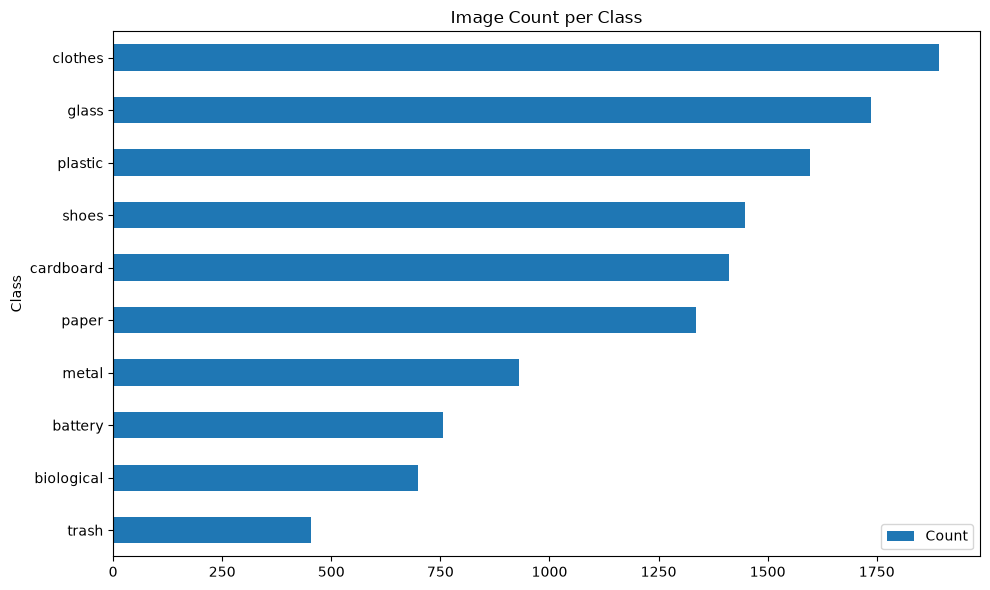

In [18]:
counts_df.sort_values("Count").plot(x="Class", y="Count", kind="barh", figsize=(10, 6))

plt.title("Image Count per Class")
plt.tight_layout()
plt.show()


## Image Resolutions


In [19]:
unique_sizes = set()

for cls in CLASS_NAMES:
    class_dir = RAW_IMAGE_DIR / cls

    for img_path in class_dir.glob("*.*"):
        try:
            img = keras.preprocessing.image.load_img(img_path)
            unique_sizes.add(img.size)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

print(f"Number of unique resolutions: {len(unique_sizes):,}")

print("\nSample resolutions:")
for size in list(unique_sizes)[:15]:
    print(size)


Number of unique resolutions: 2,407

Sample resolutions:
(306, 304)
(479, 412)
(277, 277)
(1200, 1600)
(276, 318)
(400, 613)
(315, 160)
(2968, 2984)
(580, 580)
(234, 172)
(1280, 1220)
(310, 310)
(336, 448)
(396, 499)
(931, 514)


## Corrupted Files


In [20]:
SUPPORTED_FORMATS = {"JPEG", "PNG", "BMP", "GIF"}

valid_paths = []
errors = []

for path in df["filepath"]:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            fmt = img.format

        if fmt in SUPPORTED_FORMATS:
            valid_paths.append(path)
        else:
            errors.append(("Unsupported", fmt, path))

    except Exception as e:
        errors.append(("Corrupted", str(e), path))

errors_df = pd.DataFrame(errors, columns=["Issue", "Reason", "Filepath"])

display(errors_df)


,Issue,Reason,Filepath
0,Unsupported,MPO,/home/dev/ML/Experimental/GarbageImageClassifi...
1,Unsupported,WEBP,/home/dev/ML/Experimental/GarbageImageClassifi...
2,Unsupported,MPO,/home/dev/ML/Experimental/GarbageImageClassifi...
3,Unsupported,MPO,/home/dev/ML/Experimental/GarbageImageClassifi...
4,Unsupported,WEBP,/home/dev/ML/Experimental/GarbageImageClassifi...
5,Unsupported,MPO,/home/dev/ML/Experimental/GarbageImageClassifi...
6,Unsupported,MPO,/home/dev/ML/Experimental/GarbageImageClassifi...


# ⚙️ 4. Data Preprocessing


## Corrupted Sample Removal


In [21]:
original_size = len(df)

df = df[df["filepath"].isin(valid_paths)].reset_index(drop=True)

print(f"Original images : {original_size:,}")
print(f"Valid images    : {len(df):,}")
print(f"Removed images  : {original_size - len(df):,}")


Original images : 12,259
Valid images    : 12,252
Removed images  : 7


## Label Encoding


In [22]:
df["class_id"] = df["class_name"].map(CLASS_TO_IDX)

df.sample(5)


,filepath,class_name,class_id
412,/home/dev/ML/Experimental/GarbageImageClassifi...,battery,0
963,/home/dev/ML/Experimental/GarbageImageClassifi...,biological,1
6698,/home/dev/ML/Experimental/GarbageImageClassifi...,metal,5
2936,/home/dev/ML/Experimental/GarbageImageClassifi...,clothes,3
3668,/home/dev/ML/Experimental/GarbageImageClassifi...,clothes,3


## Dataset Splitting


In [23]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["class_name"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["class_name"], random_state=SEED
)

train_df.to_csv(TRAIN_DF_PATH, index=False)
val_df.to_csv(VAL_DF_PATH, index=False)
test_df.to_csv(TEST_DF_PATH, index=False)

print(f"Train set size      : {len(train_df):,}")
print(f"Validation set size : {len(val_df):,}")
print(f"Test set size       : {len(test_df):,}")


Train set size      : 8,576
Validation set size : 1,838
Test set size       : 1,838


## Class Weight Computation


In [24]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["class_id"]),
    y=train_df["class_id"],
)

class_weight_dict = dict(enumerate(class_weights))

with open(CLASS_WEIGHTS_PATH, "w") as f:
    json.dump(class_weight_dict, f, indent=4)

print(f"Class weights:\n{class_weight_dict}")


Class weights:
{0: np.float64(1.62117202268431), 1: np.float64(1.7537832310838446), 2: np.float64(0.8680161943319838), 3: np.float64(0.6477341389728096), 4: np.float64(0.705843621399177), 5: np.float64(1.317357910906298), 6: np.float64(0.9201716738197425), 7: np.float64(0.7677708146821844), 8: np.float64(0.8457593688362919), 9: np.float64(2.7053627760252366)}


## Data Augmentation


In [25]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.1),
        layers.RandomBrightness(0.1),
    ],
)


I0000 00:00:1786106496.049576    1361 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1532 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


## Image Preprocessing


In [26]:
def load_image(path, label):

    img = load_image_tensor(path)

    return img, label


def train_preprocess(image, label):

    image = data_augmentation(image, training=True)

    image = preprocess_image(image)

    return image, label


def eval_preprocess(image, label):

    image = preprocess_image(image)

    return image, label


## Dataset Pipelines


### Training

In [27]:
train_ds = Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["class_id"].values)
)

train_ds = (
    train_ds.shuffle(len(train_df))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(train_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

train_ds.save(str(TRAIN_DS_DIR))


### Validation


In [28]:
val_ds = Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_df["class_id"].values)
)

val_ds = (
    val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(eval_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds.save(str(VAL_DS_DIR))


### Testing


In [29]:
test_ds = Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["class_id"].values)
)

test_ds = (
    test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(eval_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds.save(str(TEST_DS_DIR))


# 🧠 5. Model Selection


## Backbone Initialization


In [30]:
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
)

base_model.trainable = False


## Model Construction


In [ ]:
inputs = keras.Input(shape=base_model.input_shape[1:])

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(DROPOUT_RATE)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
)(x)

initial_model = keras.Model(inputs, outputs)

initial_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LR, weight_decay=INITIAL_WD
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),
    ],
)

initial_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,344,170 (77.61 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

# 🚀 6. Model Training


## Phase 1: Feature Extraction


### Preparation


In [32]:
train_ds = tf.data.Dataset.load(str(TRAIN_DS_DIR))
val_ds = tf.data.Dataset.load(str(VAL_DS_DIR))

with open(CLASS_WEIGHTS_PATH) as f:
    class_weight_dict = {int(k): float(v) for k, v in json.load(f).items()}

initial_callbacks = create_callbacks()


### Training


In [33]:
initial_history = initial_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=initial_callbacks,
)


Epoch 1/20


/home/dev/ML/Experimental/GarbageImageClassification/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786106629.768262    2201 service.cc:152] XLA service 0x74cb04002890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786106629.769324    2201 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-08-07 19:43:50.976518: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786106634.786498    2201 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1786106679.204217    2201 device_compiler.h:18

536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8492 - loss: 0.5936 - top3: 0.9595

2026-08-07 19:46:45.450180: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 948 bytes spill stores, 948 bytes spill loads

2026-08-07 19:47:15.979300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 860 bytes spill stores, 860 bytes spill loads

2026-08-07 19:47:26.398253: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng20{k2=1,k4=2,k5=1,k6=0,k7=0,k19=0} for conv %cudnn-conv-bias-activation.180 = (f32[14,16,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,256,1,1]{3,2,1,0} %bitcast.15563, f32[16,256,1,1]{3,2,1,0} %bitcast.15570, f32[16]{0} %bitcast.15572), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1_1/efficientnetv2-s_


Epoch 1: saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_001.keras

Epoch 1: finished saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_001.keras

Epoch 1: val_loss improved from None to 0.25886, saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/models/best.keras

Epoch 1: finished saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/models/best.keras
536/536 ━━━━━━━━━━━━━━━━━━━━ 253s 349ms/step - accuracy: 0.8492 - loss: 0.5936 - top3: 0.9595 - val_accuracy: 0.9222 - val_loss: 0.2589 - val_top3: 0.9897 - learning_rate: 0.0010
Epoch 2/20
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9045 - loss: 0.3109 - top3: 0.9864
Epoch 2: saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_002.keras

Epoch 2: finished saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoint

### Checkpoint

In [34]:
initial_model.save(INITIAL_MODEL_PATH)

with open(INITIAL_HISTORY_PATH, "w") as f:
    json.dump(initial_history.history, f)


## Phase 2: Fine-Tuning

### Preparation


In [12]:
initial_model = tf.keras.models.load_model(INITIAL_MODEL_PATH)

for idx, layer in enumerate(initial_model.layers):
    print(f"[{idx}] {layer.name}")


I0000 00:00:1786139553.227139     967 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1532 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


[0] input_layer_2
[1] efficientnetv2-s
[2] global_average_pooling2d
[3] dropout
[4] dense


In [13]:
train_ds = tf.data.Dataset.load(str(TRAIN_DS_DIR))
val_ds = tf.data.Dataset.load(str(VAL_DS_DIR))

with open(CLASS_WEIGHTS_PATH) as f:
    class_weight_dict = {int(k): float(v) for k, v in json.load(f).items()}

with open(INITIAL_HISTORY_PATH, "r") as f:
    initial_history = json.load(f)

best_loss = min(initial_history["val_loss"])
start_epoch = len(initial_history["loss"])

fine_tune_callbacks = create_callbacks(best_loss)


In [14]:
backbone = initial_model.get_layer("efficientnetv2-s")

backbone.trainable = True

freeze_until = int(len(backbone.layers) * (1 - BACKBONE_TRAINABLE_RATIO))

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

print("Trainable variables:", len(initial_model.trainable_variables))


Trainable variables: 90


In [15]:
fine_tune_model = initial_model

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR, weight_decay=FINE_TUNE_WD
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"),
    ],
)

fine_tune_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,344,170 (77.61 MB)

 Trainable params: 6,965,706 (26.57 MB)

 Non-trainable params: 13,378,464 (51.03 MB)

### Training


In [16]:
fine_tune_history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=start_epoch,
    epochs=start_epoch + FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks,
)


/home/dev/ML/Experimental/GarbageImageClassification/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 19/48


I0000 00:00:1786139583.155997    1433 service.cc:152] XLA service 0x7f7a6c025580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786139583.156054    1433 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-08-08 04:53:04.129252: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786139589.392849    1433 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-08-08 04:53:29.736190: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng56{k2=0,k12=-1,k13=2,k14=2,k15=0,k17=96,k18=0,k22=0,k23=0} for conv %cudnn-conv.300 = (f32[16,48,96,96]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,192,96,96]{3,2,1,0} %bitcast.120010, f32[48,192,1,1]{3,2,1,0} %bitcast.120017), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op

536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8956 - loss: 0.3131 - top3: 0.9864

2026-08-08 04:56:43.937324: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 948 bytes spill stores, 948 bytes spill loads

2026-08-08 04:57:15.351962: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 860 bytes spill stores, 860 bytes spill loads

2026-08-08 04:57:30.837725: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{} for conv %cudnn-conv.344 = (f32[14,1280,12,12]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,256,12,12]{3,2,1,0} %bitcast.21298, f32[1280,256,1,1]{3,2,1,0} %bitcast.21305), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="functional_1_1/efficientnetv2-s_1/top_conv_1/convolution" source_file="/home/dev/ML/Experimental/GarbageImageCla


Epoch 19: saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_019.keras

Epoch 19: finished saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_019.keras

Epoch 19: val_loss did not improve from 0.17317
536/536 ━━━━━━━━━━━━━━━━━━━━ 304s 415ms/step - accuracy: 0.8956 - loss: 0.3131 - top3: 0.9864 - val_accuracy: 0.9342 - val_loss: 0.2146 - val_top3: 0.9869 - learning_rate: 1.0000e-05
Epoch 20/48
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9213 - loss: 0.2329 - top3: 0.9909
Epoch 20: saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_020.keras

Epoch 20: finished saving model to /home/dev/ML/Experimental/GarbageImageClassification/outputs/checkpoints/epoch_020.keras

Epoch 20: val_loss did not improve from 0.17317
536/536 ━━━━━━━━━━━━━━━━━━━━ 178s 332ms/step - accuracy: 0.9213 - loss: 0.2329 - top3: 0.9909 - val_accuracy: 0.9412 - val_loss: 0.189

## Training History

In [17]:
history_dict = {
    "initial": initial_history,
    "fine_tune": fine_tune_history.history,
}

with open(HISTORY_JSON_PATH, "w") as f:
    json.dump(history_dict, f)


In [18]:
train_acc_history = (
    history_dict["initial"]["accuracy"] + history_dict["fine_tune"]["accuracy"]
)

val_acc_history = (
    history_dict["initial"]["val_accuracy"] + history_dict["fine_tune"]["val_accuracy"]
)

train_loss_history = history_dict["initial"]["loss"] + history_dict["fine_tune"]["loss"]

val_loss_history = (
    history_dict["initial"]["val_loss"] + history_dict["fine_tune"]["val_loss"]
)

epoch_indices = range(1, len(train_acc_history) + 1)
best_idx = np.argmax(val_acc_history)
best_epoch = best_idx + 1

history_df = pd.DataFrame(
    {
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
    }
)

history_df.to_csv(HISTORY_CSV_PATH, index=False)


# 📊 7. Model Evaluation


## Result Loading


In [19]:
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_ds = tf.data.Dataset.load(str(TEST_DS_DIR))


In [20]:
training_history = pd.read_csv(HISTORY_CSV_PATH)

train_acc_history = training_history["train_acc"]
val_acc_history = training_history["val_acc"]
train_loss_history = training_history["train_loss"]
val_loss_history = training_history["val_loss"]

epoch_indices = range(1, len(train_acc_history) + 1)
best_idx = np.argmin(val_loss_history)
best_epoch = best_idx + 1


## Training and Validation Performance


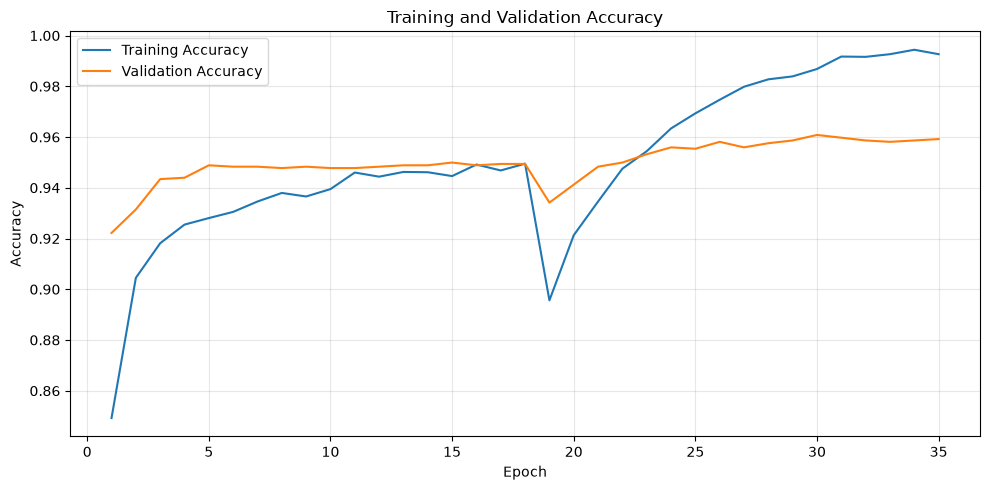

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(epoch_indices, train_acc_history, label="Training Accuracy")

plt.plot(epoch_indices, val_acc_history, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_and_validation_accuracy.svg", bbox_inches="tight")
plt.show()


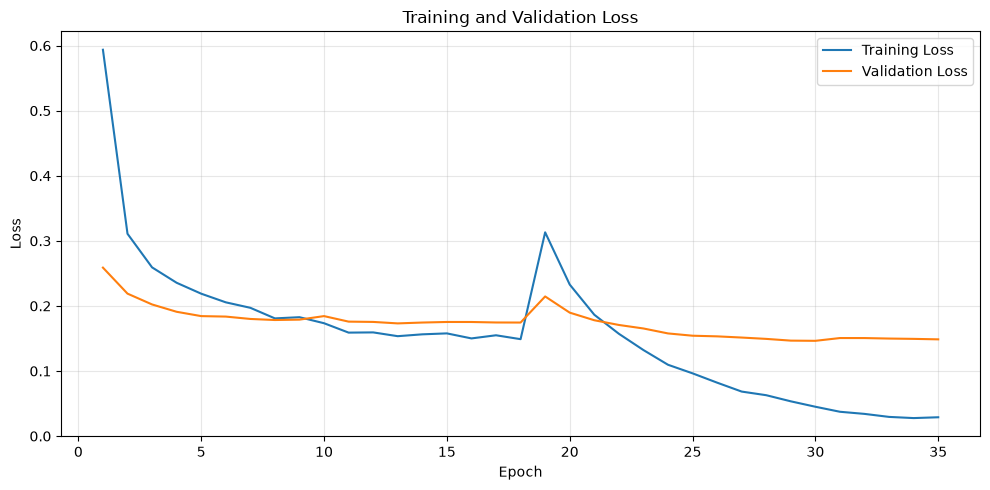

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(epoch_indices, train_loss_history, label="Training Loss")

plt.plot(epoch_indices, val_loss_history, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_and_validation_loss.svg", bbox_inches="tight")
plt.show()


## Best Validation Loss


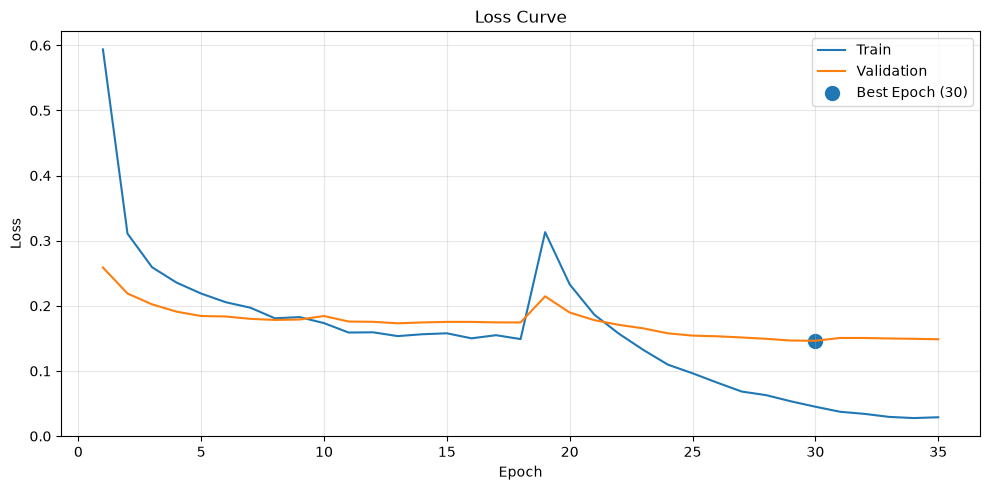

In [23]:
best_loss = min(val_loss_history)

plt.figure(figsize=(10, 5))

plt.plot(epoch_indices, train_loss_history, label="Train")
plt.plot(epoch_indices, val_loss_history, label="Validation")

plt.scatter(best_epoch, best_loss, s=100, label=f"Best Epoch ({best_epoch})")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "loss_curve.svg", bbox_inches="tight")
plt.show()


## Test Evaluation


In [24]:
results = best_model.evaluate(test_ds, verbose=1, return_dict=True)

test_acc = results["accuracy"]
test_loss = results["loss"]
test_top3 = results["top3"]

print(f"\nTest accuracy  : {test_acc:.4f}")
print(f"Test loss      : {test_loss:.4f}")
print(f"Top-3 accuracy : {test_top3:.4f}")


115/115 ━━━━━━━━━━━━━━━━━━━━ 45s 264ms/step - accuracy: 0.9489 - loss: 0.1858 - top3: 0.9940

Test accuracy  : 0.9489
Test loss      : 0.1858
Top-3 accuracy : 0.9940


## Model Predictions


In [25]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(preds, axis=1))


2026-08-08 05:47:46.266230: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Classification Report


In [26]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

     battery       0.97      0.97      0.97       114
  biological       0.91      1.00      0.95       105
   cardboard       0.95      0.94      0.94       211
     clothes       1.00      0.99      1.00       284
       glass       0.96      0.92      0.94       260
       metal       0.88      0.96      0.92       140
       paper       0.94      0.89      0.91       200
     plastic       0.94      0.93      0.93       239
       shoes       1.00      1.00      1.00       217
       trash       0.81      0.88      0.85        68

    accuracy                           0.95      1838
   macro avg       0.94      0.95      0.94      1838
weighted avg       0.95      0.95      0.95      1838



## Confusion Matrix


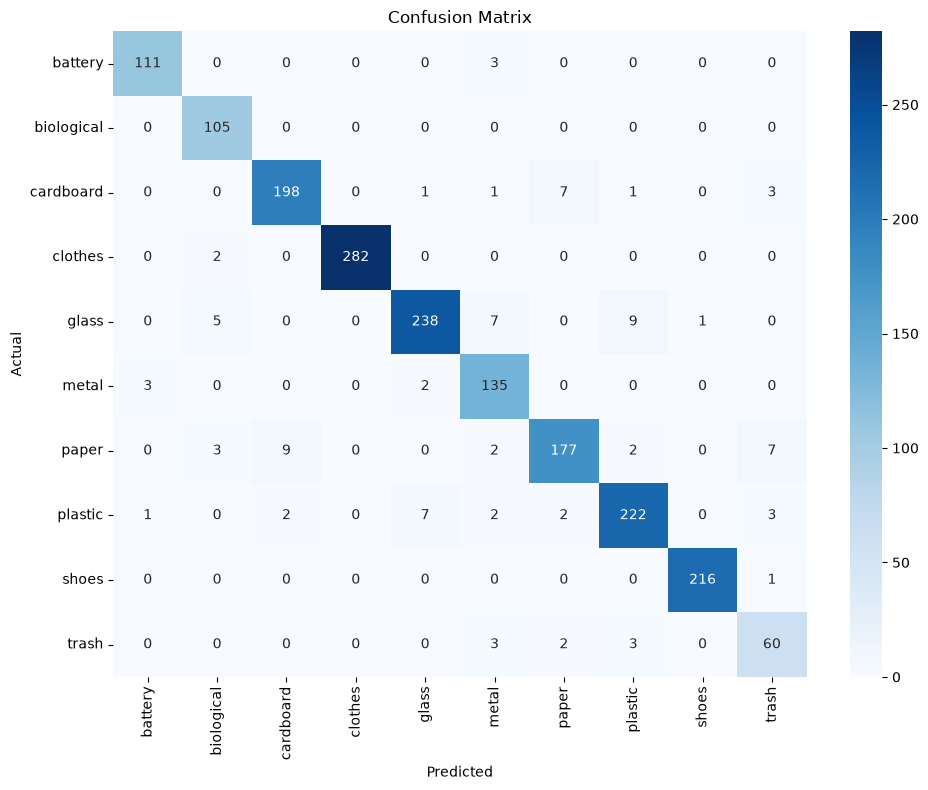

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.svg", bbox_inches="tight")
plt.show()


## Final Model Performance

In [28]:
print("🌟 Final Model Performance")

print(f"Best epoch          : {best_epoch}")

print(f"Train accuracy      : {train_acc_history[best_idx]:.4f}")
print(f"Train loss          : {train_loss_history[best_idx]:.4f}")

print(f"Validation accuracy : {val_acc_history[best_idx]:.4f}")
print(f"Validation loss     : {val_loss_history[best_idx]:.4f}")

print(f"Test accuracy       : {test_acc:.4f}")
print(f"Test loss           : {test_loss:.4f}")

print(f"Top-3 accuracy      : {test_top3:.4f}")


🌟 Final Model Performance
Best epoch          : 30
Train accuracy      : 0.9868
Train loss          : 0.0451
Validation accuracy : 0.9608
Validation loss     : 0.1464
Test accuracy       : 0.9489
Test loss           : 0.1858
Top-3 accuracy      : 0.9940


# 🌍 8. Deployment


## Model Loading


In [29]:
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)


## Saved Model Export


In [30]:
best_model.export(SAVED_MODEL_DIR)

print("\nSavedModel files:", os.listdir(SAVED_MODEL_DIR))

saved_model = tf.saved_model.load(SAVED_MODEL_DIR)

print("\nAvailable signatures:", list(saved_model.signatures.keys()))

serving_fn = saved_model.signatures["serving_default"]

print("\nInput signature:")
print(serving_fn.structured_input_signature)

print("\nOutputs:")
print(serving_fn.structured_outputs)


INFO:tensorflow:Assets written to: /home/dev/ML/Experimental/GarbageImageClassification/outputs/saved_model/assets


INFO:tensorflow:Assets written to: /home/dev/ML/Experimental/GarbageImageClassification/outputs/saved_model/assets


Saved artifact at '/home/dev/ML/Experimental/GarbageImageClassification/outputs/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140164331770064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331779856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331771408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331773328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331773136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331780816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331778512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331780624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331766032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164331778704: TensorSpe

## TFLite Conversion

In [31]:
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(TFLITE_MODEL_PATH, "wb") as f:
    f.write(tflite_model)

with open(TFLITE_LABEL_PATH, "w") as f:
    for label in CLASS_NAMES:
        f.write(label + "\n")

size_mb = os.path.getsize(TFLITE_MODEL_PATH) / 1024 / 1024

print(f"\nFile size: {size_mb:2f} MB")


W0000 00:00:1786142908.315608     967 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1786142908.315855     967 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-08-08 05:48:28.328951: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /home/dev/ML/Experimental/GarbageImageClassification/outputs/saved_model
2026-08-08 05:48:28.350925: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-08-08 05:48:28.350951: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /home/dev/ML/Experimental/GarbageImageClassification/outputs/saved_model
I0000 00:00:1786142908.774773     967 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-08-08 05:48:28.825443: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-08-08 05:48:33.162843: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bun


File size: 20.964691 MB


## TF.js Conversion


In [32]:
!sed -i 's/raise VersionError(msg)/print("Protobuf Version Warning Ignored:", msg)/g' \
"{PROJECT_DIR}/.venv/lib/python3.12/site-packages/google/protobuf/runtime_version.py"

!"{PROJECT_DIR}/.venv/bin/pip" install "setuptools<70.0.0"


In [33]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    "{SAVED_MODEL_DIR}" \
    "{TFJS_DIR}"


2026-08-08 05:48:41.946852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786142922.040645   17141 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786142922.066532   17141 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786142922.247046   17141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786142922.247186   17141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786142922.247191   17141 computation_placer.cc:177] computation placer alr

# ✨ 9. Inference


## Preparation


In [34]:
test_df = pd.read_csv(TEST_DF_PATH)


In [35]:
def predict_image(model, image_path):

    img = load_image_tensor(image_path)

    img = preprocess_image(img)

    img = tf.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)

    predicted_idx = np.argmax(pred[0])
    confidence = np.max(pred[0])

    return predicted_idx, confidence


def tflite_predict(image_path):

    img = load_image_tensor(image_path)

    img = preprocess_image(img)

    img = tf.expand_dims(img, axis=0)

    interpreter.set_tensor(input_details[0]["index"], img.numpy())

    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    pred_idx = np.argmax(output[0])
    confidence = np.max(output[0])

    return pred_idx, confidence


def plot_predictions(
    sample_df,
    predict_fn,
    class_mapping,
    title="Inference Results",
    n_cols=4,
):

    n_images = len(sample_df)

    n_rows = math.ceil(n_images / n_cols)

    plt.figure(figsize=(18, 4 * n_rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):

        image_path = row["filepath"]

        actual = row["class_name"]

        pred_idx, conf = predict_fn(image_path)

        predicted = class_mapping[pred_idx]

        img = Image.open(image_path)

        correct = actual == predicted

        plt.subplot(n_rows, n_cols, i + 1)

        plt.imshow(img)

        status = "✓" if correct else "✗"

        plt.title(
            f"{status} {predicted}\n" f"({conf:.1%})\n" f"Actual: {actual}",
            color="green" if correct else "red",
            fontsize=10,
        )

        plt.axis("off")

    plt.suptitle(
        title,
        fontsize=20,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    plt.show()


In [36]:
sample_df = (
    test_df.groupby("class_name").sample(n=3, random_state=SEED).reset_index(drop=True)
)

sample_df.head(10)


,filepath,class_name,class_id
0,/home/dev/ML/Experimental/GarbageImageClassifi...,battery,0
1,/home/dev/ML/Experimental/GarbageImageClassifi...,battery,0
2,/home/dev/ML/Experimental/GarbageImageClassifi...,battery,0
3,/home/dev/ML/Experimental/GarbageImageClassifi...,biological,1
4,/home/dev/ML/Experimental/GarbageImageClassifi...,biological,1
5,/home/dev/ML/Experimental/GarbageImageClassifi...,biological,1
6,/home/dev/ML/Experimental/GarbageImageClassifi...,cardboard,2
7,/home/dev/ML/Experimental/GarbageImageClassifi...,cardboard,2
8,/home/dev/ML/Experimental/GarbageImageClassifi...,cardboard,2
9,/home/dev/ML/Experimental/GarbageImageClassifi...,clothes,3


## SavedModel Inference


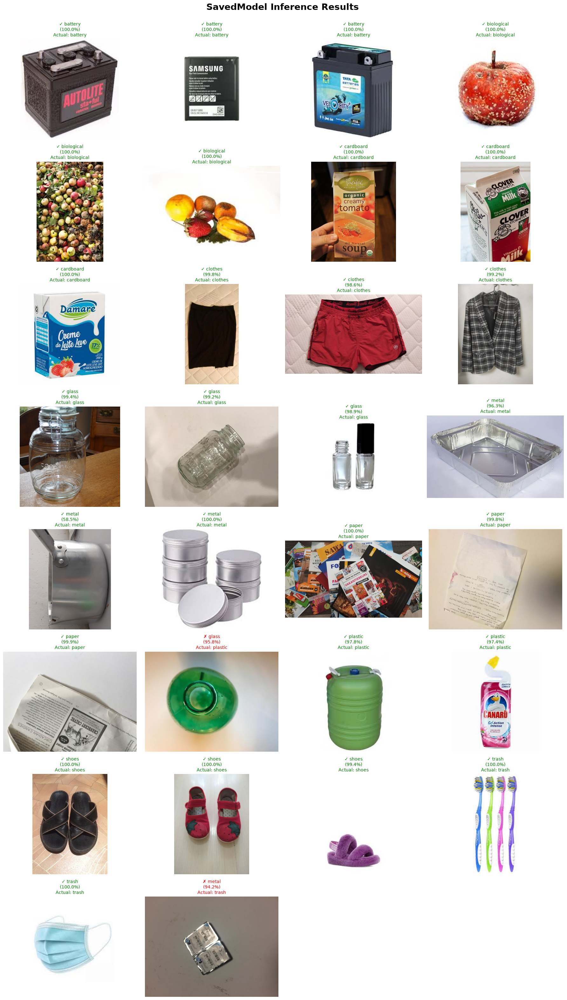

In [37]:
plot_predictions(
    sample_df=sample_df,
    predict_fn=lambda path: predict_image(best_model, path),
    class_mapping=IDX_TO_CLASS,
    title="SavedModel Inference Results",
)


## TFLite Inference


In [38]:
interpreter = Interpreter(model_path=TFLITE_MODEL_PATH)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Shape:", input_details[0]["shape"])
print("Output Shape:", output_details[0]["shape"])

with open(TFLITE_LABEL_PATH, "r") as f:
    class_names = [line.strip() for line in f.readlines()]

print("\nClass names:", class_names)


Input Shape: [  1 384 384   3]
Output Shape: [ 1 10]

Class names: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


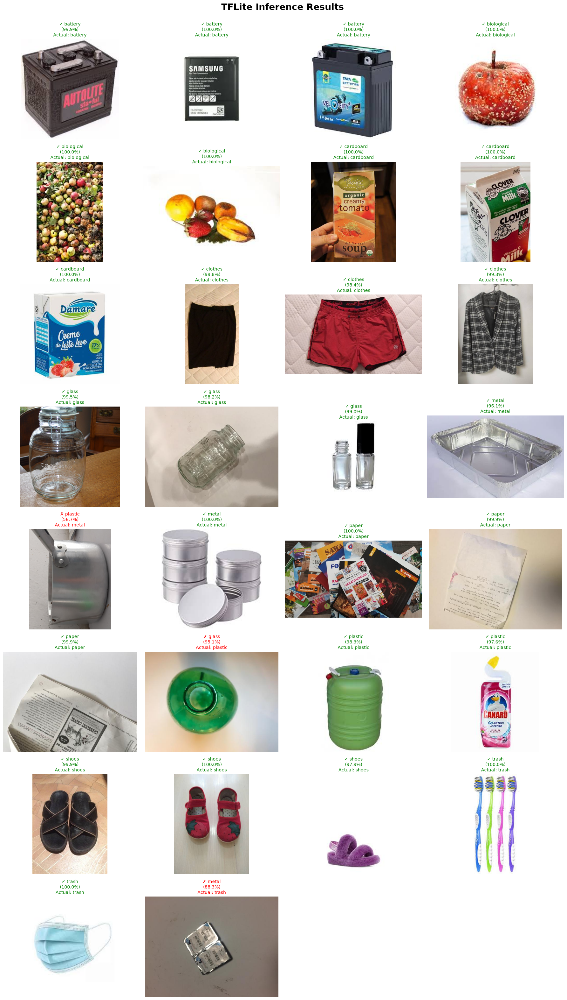

In [39]:
plot_predictions(
    sample_df=sample_df,
    predict_fn=tflite_predict,
    class_mapping=class_names,
    title="TFLite Inference Results",
)
